# Task-1 : Face Mask Detection using CNN

#### 1. Problem Understanding
This project is a binary classification problem.
- Input: Face images
- Output: Mask / No Mask

#### 2. Data Collection
For this step, we need to gather the data.
- Use datasets like:
  - Kaggle Face Mask Dataset
  - Real-world images (optional)

In [ ]:
# Install kagglehub to download the dataset directly
!pip install kagglehub -q

import kagglehub
import os

# Download the dataset
path = kagglehub.dataset_download("omkargurav/face-mask-dataset")
input_data_dir = os.path.join(path, 'data')

print("Dataset downloaded to:", input_data_dir)

Using Colab cache for faster access to the 'face-mask-dataset' dataset.
Dataset downloaded to: /kaggle/input/face-mask-dataset/data


#### 3. Data Preprocessing
Before feeding the images to the model, we need to format them correctly.
- Resize images (e.g., 224x224 or 128x128)
- Normalize pixel values (0–1)
- Convert labels into numerical format (0, 1)
- Split dataset:
  - Train (70%)
  - Validation (15%)
  - Test (15%)

In [ ]:
# Install split-folders to manage the 70/15/15 split
!pip install split-folders -q
import splitfolders

output_dir = "./dataset_split"

# Splitting the dataset into Train, Validation, and Test
splitfolders.ratio(
    input_data_dir,
    output=output_dir,
    seed=42,
    ratio=(0.7, 0.15, 0.15)
)

print("Data splitting complete. Folders created in:", output_dir)

Copying files: 7553 files [01:39, 75.86 files/s]

Data splitting complete. Folders created in: ./dataset_split


#### 4. Data Augmentation
To ensure the model doesn't just memorize the training data, we introduce slight variations to the images. We will use ImageDataGenerator (Keras) to improve generalization using:
- Rotation
- Flipping
- Zoom
- Shearing

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Setup augmentation for training data and normalize pixel values
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2
)

# Only normalize pixel values for validation and test data
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Load data, resize to 128x128, and convert labels to numerical binary format
train_generator = train_datagen.flow_from_directory(
    f"{output_dir}/train",
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    f"{output_dir}/val",
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

test_generator = val_test_datagen.flow_from_directory(
    f"{output_dir}/test",
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 5286 images belonging to 2 classes.
Found 1132 images belonging to 2 classes.
Found 1135 images belonging to 2 classes.


#### 5. Build CNN Model
Now we define the neural network. We will use a basic CNN Architecture:
- Convolution Layer + ReLU
- MaxPooling
- Dropout
- Fully Connected Layer
- Output Layer (Sigmoid for binary)

Example flow: Conv -> ReLU -> Pool -> Conv -> Pool -> Flatten -> Dense -> Output

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Building the architecture based on the specified flow
model = Sequential([
    # Convolution Layer + ReLU
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    # MaxPooling
    MaxPooling2D(pool_size=(2, 2)),

    # Second Conv and Pool block
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Flatten
    Flatten(),

    # Fully Connected Layer
    Dense(128, activation='relu'),
    # Dropout
    Dropout(0.5),

    # Output Layer (Sigmoid for binary classification)
    Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

#### 6. Model Training
With the architecture built, we compile and train the model using these specific parameters:
- Loss Function: Binary Crossentropy
- Optimizer: Adam
- Metrics: Accuracy

In [ ]:
# Compile the model
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
  4/166 ━━━━━━━━━━━━━━━━━━━━ 2:45 1s/step - accuracy: 0.5859 - loss: 0.7914

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


166/166 ━━━━━━━━━━━━━━━━━━━━ 124s 733ms/step - accuracy: 0.8460 - loss: 0.3717 - val_accuracy: 0.8860 - val_loss: 0.2683
Epoch 2/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 109s 654ms/step - accuracy: 0.8852 - loss: 0.2765 - val_accuracy: 0.8631 - val_loss: 0.2889
Epoch 3/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 107s 643ms/step - accuracy: 0.8897 - loss: 0.2578 - val_accuracy: 0.9011 - val_loss: 0.2364
Epoch 4/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 105s 635ms/step - accuracy: 0.9056 - loss: 0.2336 - val_accuracy: 0.9090 - val_loss: 0.2188
Epoch 5/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 105s 632ms/step - accuracy: 0.9111 - loss: 0.2139 - val_accuracy: 0.9125 - val_loss: 0.1994
Epoch 6/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 109s 654ms/step - accuracy: 0.9166 - loss: 0.1966 - val_accuracy: 0.9267 - val_loss: 0.1858
Epoch 7/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 105s 631ms/step - accuracy: 0.9228 - loss: 0.1833 - val_accuracy: 0.9187 - val_loss: 0.1946
Epoch 8/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 107s 645ms/step - accuracy: 0.9222 - loss: 0.18

#### 7. Model Evaluation
Finally, we test how well the model learned by running it against our unseen test data. We evaluate based on:
- Accuracy
- Confusion Matrix
- Precision & Recall

36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 160ms/step - accuracy: 0.9189 - loss: 0.2229

Overall Test Accuracy: 91.89%
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 172ms/step


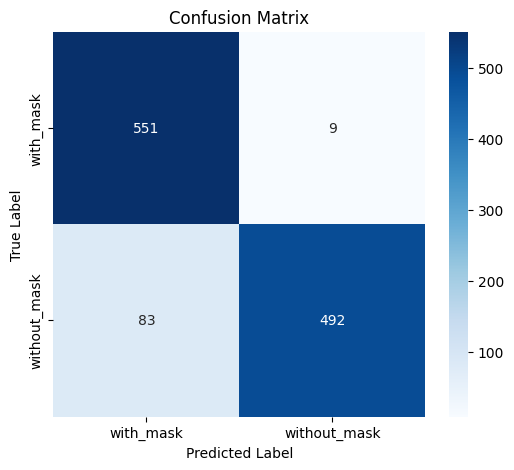


Classification Report (Precision & Recall):
              precision    recall  f1-score   support

   with_mask       0.87      0.98      0.92       560
without_mask       0.98      0.86      0.91       575

    accuracy                           0.92      1135
   macro avg       0.93      0.92      0.92      1135
weighted avg       0.93      0.92      0.92      1135



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# 1. Overall Accuracy
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"\nOverall Test Accuracy: {test_accuracy * 100:.2f}%")

# Generate predictions to build the matrix and report
test_generator.reset()
predictions = model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int)
y_true = test_generator.classes

# 2. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 3. Precision & Recall
print("\nClassification Report (Precision & Recall):")
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))

#### 8. Project Insights and Analysis

Let's visualize the training history to understand how the model learned over epochs.

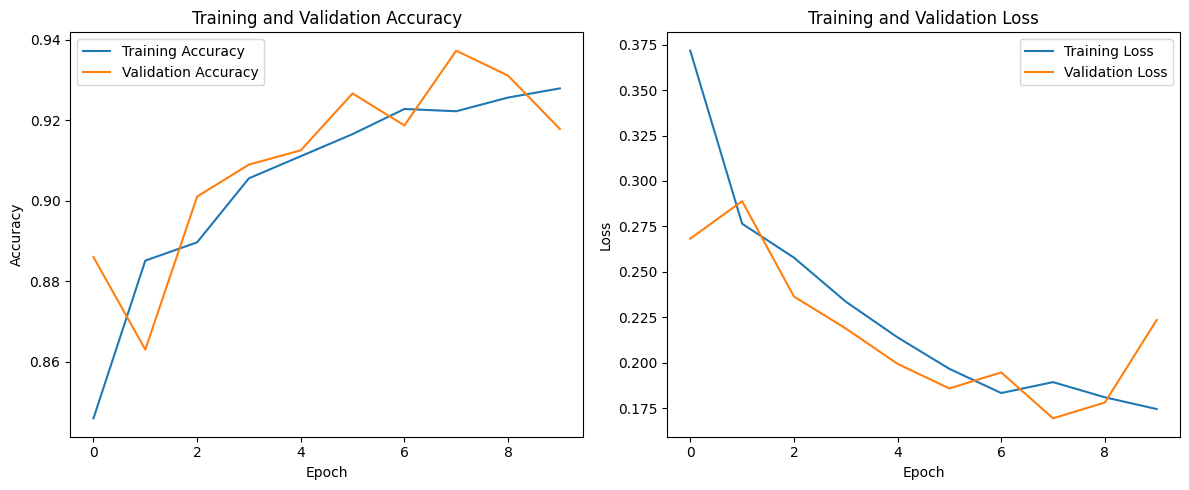

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

##### Analysis of Training History:

From the plots above, we can observe:

*   **Accuracy:** Both training and validation accuracy generally increase over the epochs. The validation accuracy shows some fluctuations but overall trends upward, indicating the model is learning effectively.
*   **Loss:** Correspondingly, both training and validation loss decrease, which is a good sign. There might be a slight divergence in the later epochs where validation loss starts to fluctuate or increase slightly while training loss continues to decrease, which could be an early sign of overfitting. However, the dropout layer seems to be helping mitigate this to some extent.

##### Interpretation of Evaluation Metrics:

The model was evaluated on the test set, yielding an **Overall Test Accuracy of 91.89%**.

**Confusion Matrix Breakdown:**

```
[[551,   9],
 [ 83, 492]]
```

Considering 'with_mask' as class 0 and 'without_mask' as class 1:

*   **True Negatives (TN): 551** (Images with masks correctly predicted as 'with mask')
*   **False Positives (FP): 9** (Images with masks incorrectly predicted as 'without mask' - Type I error)
*   **False Negatives (FN): 83** (Images without masks incorrectly predicted as 'with mask' - Type II error)
*   **True Positives (TP): 492** (Images without masks correctly predicted as 'without mask')

**Classification Report (Precision & Recall):**

```
              precision    recall  f1-score   support

   with_mask       0.87      0.98      0.92       560
without_mask       0.98      0.86      0.91       575

    accuracy                           0.92      1135
   macro avg       0.93      0.92      0.92      1135
weighted avg       0.93      0.92      0.92      1135
```

*   **'with_mask' class (0):**
    *   **Precision (0.87):** When the model predicts 'with mask', it is correct 87% of the time. This means there are some instances where it wrongly identifies a 'without mask' as 'with mask' (our False Negatives of 83).
    *   **Recall (0.98):** The model correctly identifies 98% of all actual 'with mask' cases. This indicates that the model is very good at not missing people who are wearing masks.

*   **'without_mask' class (1):**
    *   **Precision (0.98):** When the model predicts 'without mask', it is correct 98% of the time. This means it is very reliable when it says someone is not wearing a mask.
    *   **Recall (0.86):** The model correctly identifies 86% of all actual 'without mask' cases. This means it misses some instances where people are not wearing masks, mistakenly classifying them as 'with mask' (our False Positives of 9).

**Overall:**

The model exhibits a strong overall accuracy of nearly 92%. It shows a higher recall for 'with_mask' (meaning it's good at detecting masks) and a higher precision for 'without_mask' (meaning its predictions of 'without mask' are highly trustworthy). The primary area for improvement seems to be reducing False Negatives for the 'without_mask' class, where people without masks are sometimes missed.